# Test with Dataset from CellTypist

In [1]:
import anndata as ad

# Read data from h5ad files
adata = ad.io.read_h5ad('../CellTypistDataset/global.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 329762 × 36601
    obs: 'Organ', 'Donor', 'Chemistry', 'Cell_category', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype'
    obsm: 'X_umap'


In [2]:
# Filter blood data
adata = adata[adata.obs['Organ'] == 'BLD'].copy()
print(adata)

AnnData object with n_obs × n_vars = 27620 × 36601
    obs: 'Organ', 'Donor', 'Chemistry', 'Cell_category', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype'
    obsm: 'X_umap'


## Preprocessing

In [3]:
import scanpy as sc

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)


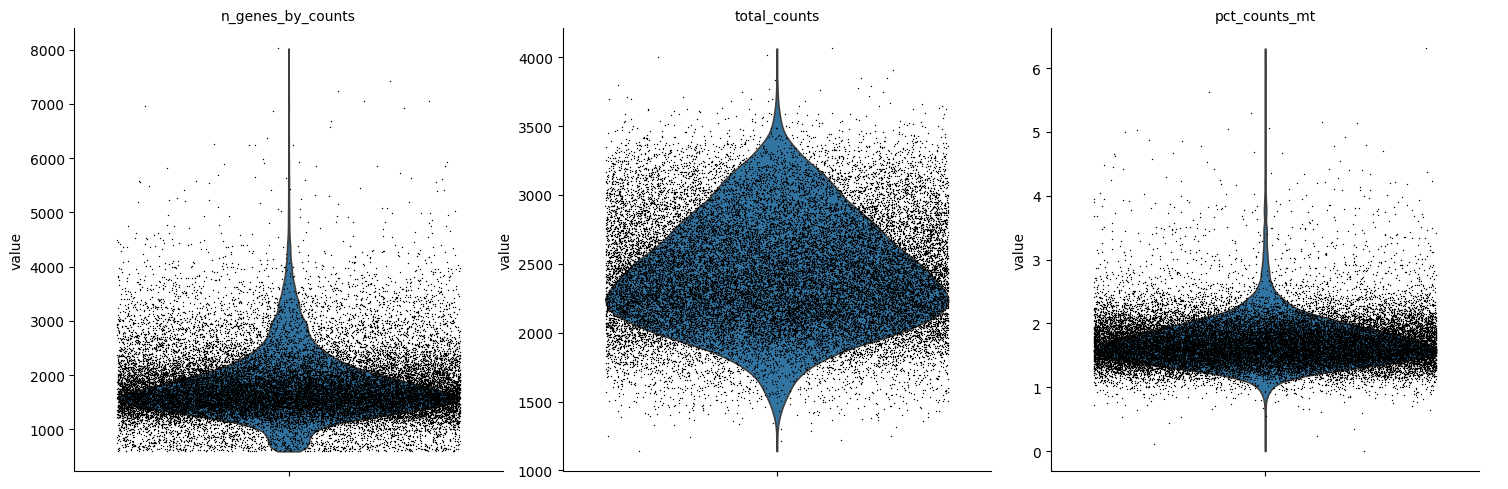

In [4]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

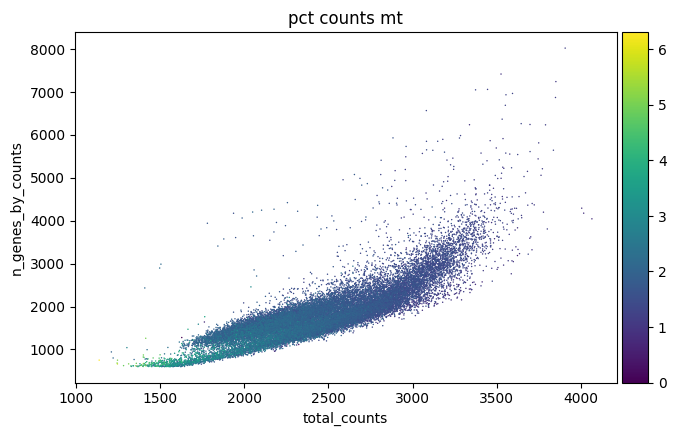

In [5]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [6]:
# Zellen mit mehr als 5% MT-Reads entfernen
#adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

# Alle Gene behalten, die NICHT mt oder ribo sind
# (HB Gene werden meistens auch hier entfernt)
adata = adata[:, ~adata.var["mt"]].copy()
adata = adata[:, ~adata.var["ribo"]].copy()
adata = adata[:, ~adata.var["hb"]].copy()

#TODO: Doppelt sich das nicht mit der ersten filter option in dieser zelle? -> es kommt mit und ohne erste Zeile dieselbe Anzahl an Features raus

In [7]:
print(adata)

AnnData object with n_obs × n_vars = 27620 × 36473
    obs: 'Organ', 'Donor', 'Chemistry', 'Cell_category', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'X_umap'


In [8]:
# Zellzyklusgene löschen

# Standard-Genlisten für Zellzyklus laden (für Menschen)
cell_cycle_genes = [x.strip() for x in open('regev_hs_genes.txt')] # Datei muss vorliegen
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]

# Score berechnen (wie sehr teilt sich eine Zelle?)
sc.tl.score_cells_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

# OPTION A: Den Effekt der Zellzyklus-Scores "rausrechnen" (Regression)
# Das ist sauberer als die Gene einfach zu löschen
sc.pp.regress_out(adata, ['S_score', 'G2M_score'])

# OPTION B: Die Zellzyklus-Gene direkt aus der Matrix löschen
# (Nur empfohlen, wenn die Regression zu lange dauert)
#adata = adata[:, ~adata.var_names.isin(cell_cycle_genes)].copy()

FileNotFoundError: [Errno 2] No such file or directory: 'regev_hs_genes.txt'

In [8]:
# Doublet Detection)
sc.pp.scrublet(adata, batch_key="Donor")

In [10]:
import json

with open('../scumi-dev/R/marker_gene/human_pbmc_marker.json', 'r') as file:
    marker_genes = json.load(file)

In [15]:
print(X)
print(type(X))

                               MIR1302-2HG  FAM138A  OR4F5  AL627309.1  \
Pan_T7980361_AAACCTGAGTGCAAGC          0.0      0.0    0.0         0.0   
Pan_T7980361_AAACCTGCAATACGCT          0.0      0.0    0.0         0.0   
Pan_T7980361_AAACCTGTCCATGCTC          0.0      0.0    0.0         0.0   
Pan_T7980361_AAACCTGTCTGAAAGA          0.0      0.0    0.0         0.0   
Pan_T7980361_AAACCTGTCTGCGTAA          0.0      0.0    0.0         0.0   
...                                    ...      ...    ...         ...   
CZINY-0112_TTGTTTGTCGAACGCC            0.0      0.0    0.0         0.0   
CZINY-0112_TTTAGTCAGAGCTGAC            0.0      0.0    0.0         0.0   
CZINY-0112_TTTAGTCCAGCATTGT            0.0      0.0    0.0         0.0   
CZINY-0112_TTTCACAGTCAAAGAT            0.0      0.0    0.0         0.0   
CZINY-0112_TTTCGATGTGTTTCTT            0.0      0.0    0.0         0.0   

                               AL627309.3  AL627309.2  AL627309.5  AL627309.4  \
Pan_T7980361_AAACCTGAGTGCAAGC 

In [16]:
for marker in marker_genes:
    for gene in marker:
        if gene in X.columns:
            print(gene)

## Normalization

In [9]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

## Model Training

In [10]:
from sklearn.model_selection import train_test_split

# Prepare Data for training
X = adata.to_df()
gene_names = adata.var_names
y = adata.obs['Manually_curated_celltype']

print(X)
print('---')
print(gene_names)
print('---')
print(y)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 23, test_size = 0.5)

                               MIR1302-2HG  FAM138A  OR4F5  AL627309.1  \
Pan_T7980361_AAACCTGAGTGCAAGC          0.0      0.0    0.0         0.0   
Pan_T7980361_AAACCTGCAATACGCT          0.0      0.0    0.0         0.0   
Pan_T7980361_AAACCTGTCCATGCTC          0.0      0.0    0.0         0.0   
Pan_T7980361_AAACCTGTCTGAAAGA          0.0      0.0    0.0         0.0   
Pan_T7980361_AAACCTGTCTGCGTAA          0.0      0.0    0.0         0.0   
...                                    ...      ...    ...         ...   
CZINY-0112_TTGTTTGTCGAACGCC            0.0      0.0    0.0         0.0   
CZINY-0112_TTTAGTCAGAGCTGAC            0.0      0.0    0.0         0.0   
CZINY-0112_TTTAGTCCAGCATTGT            0.0      0.0    0.0         0.0   
CZINY-0112_TTTCACAGTCAAAGAT            0.0      0.0    0.0         0.0   
CZINY-0112_TTTCGATGTGTTTCTT            0.0      0.0    0.0         0.0   

                               AL627309.3  AL627309.2  AL627309.5  AL627309.4  \
Pan_T7980361_AAACCTGAGTGCAAGC 

## Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

#model = RandomForestClassifier(criterion = "entropy", n_estimators = 100)
model = RandomForestClassifier()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.799637943519189


In [29]:
from test_robustness import compute_model_score_and_robustness

compute_model_score_and_robustness(model, X_test, y_test, None)

Baseline accuracy score 0.7996
Random dropout accuracy score 0.7890


### Grid Search

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Random Forest Modell
model = RandomForestClassifier()

# Parameter für das Grid
param_grid = {
    'n_estimators': [100, 200],         # Anzahl der Bäume
    'max_depth': [10, 20, None],            # Maximale Tiefe der Bäume
    'min_samples_split': [2, 5],        # Minimale Stichproben für den Split
    'min_samples_leaf': [1, 2],          # Minimale Stichproben pro Blatt
    'max_features': ['sqrt', 'log2', None]  # Anzahl der Merkmale, die für den Split verwendet werden
}

# GridSearchCV initialisieren
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=5)

# GridSearchCV fitten
grid_search.fit(X_train, y_train)

# Die besten Parameter ausgeben
print("Beste Parameter:", grid_search.best_params_)
print("Beste Genauigkeit:", grid_search.best_score_)

# Modell mit den besten Parametern auf dem Testset evaluieren
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Testgenauigkeit mit den besten Parametern:", test_accuracy)

/home/boolean/Documents/Uni/Semester_2/Project_CLACELL/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


KeyboardInterrupt: 

## LogisticRegression

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.9177407675597393


In [33]:
from test_robustness import compute_model_score_and_robustness

compute_model_score_and_robustness(model, X_test, y_test, None)

Baseline accuracy score 0.9177
Random dropout accuracy score 0.9148


## SVM

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel="poly", C=0.001)
model.fit(X_train, y_train)
 
print(model.score(X_test, y_test))

In [21]:
from test_robustness import compute_model_score_and_robustness

compute_model_score_and_robustness(model, X_test, y_test, None)

Baseline accuracy score 0.5064
Random dropout accuracy score 0.4571


## LightGBM

In [17]:
import lightgbm as lgbm

#modelLGBM = LGBMClassifier(boosting_type='dart', learning_rate=0.03752055855124281, 
#                           max_depth=10, n_estimators=444, num_leaves=36, verbose=0)
modelLGBM = lgbm.LGBMClassifier()
modelLGBM.fit(X_train, y_train)

print(modelLGBM.score(X_test, y_test))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.717152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2575937
[LightGBM] [Info] Number of data points in the train set: 13810, number of used features: 16684
[LightGBM] [Info] Start training from score -6.894091
[LightGBM] [Info] Start training from score -8.434536
[LightGBM] [Info] Start training from score -1.549708
[LightGBM] [Info] Start training from score -8.434536
[LightGBM] [Info] Start training from score -4.823618
[LightGBM] [Info] Start training from score -7.741389
[LightGBM] [Info] Start training from score -5.661947
[LightGBM] [Info] Start training from score -9.533148
[LightGBM] [Info] Start training from score -7.587238
[LightGBM] [Info] Start training from score -8.146854
[LightGBM] [Info] Start training from score -5.507797
[LightGBM] [Info] Start training from score -4.814649
[LightGBM] [Info] Start training from score -7.453707
[Li

In [18]:
from test_robustness import compute_model_score_and_robustness

compute_model_score_and_robustness(modelLGBM, X_test, y_test, None)

Baseline accuracy score 0.2856
Random dropout accuracy score 0.2559


## XGBoost

In [23]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Labels encoden
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Modell
model = XGBClassifier()

model.fit(X_train, y_train_enc)

print(model.score(X_test, y_test_enc))

0.9165821868211441


In [25]:
from test_robustness import compute_model_score_and_robustness

compute_model_score_and_robustness(model, X_test, y_test_enc, None)

Baseline accuracy score 0.9166
Random dropout accuracy score 0.9011


## Save and load models

In [34]:
import pickle

with open("models/logisticregression.pkl", "wb") as f:
    pickle.dump(model, f)

In [31]:
with open("models/xgboost.pkl", "rb") as f:
    xgboost = pickle.load(f)

compute_model_score_and_robustness(xgboost, X_test, y_test_enc, None)

Baseline accuracy score 0.9166
Random dropout accuracy score 0.9051
